# Dataset Statistics
Inspect metadata, spacing distributions, and scan-size trends.

In [1]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from pandas.errors import EmptyDataError
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

metadata_csv = ROOT / 'data' / 'metadata.csv'
ingest_script = ROOT / 'scripts' / 'run_ingest.py'

sns.set_theme(style='whitegrid')
print(f'Using metadata file: {metadata_csv}')

Using metadata file: C:\Users\karth\PrediCT\data\metadata.csv


In [2]:
df = pd.DataFrame()

try:
    needs_generation = (not metadata_csv.exists()) or (metadata_csv.stat().st_size == 0)
except OSError:
    needs_generation = True

if needs_generation:
    print('metadata.csv is missing or empty. Running ingestion to generate metadata...')
    if not ingest_script.exists():
        raise FileNotFoundError(f'Ingest script not found: {ingest_script}')
    subprocess.run([sys.executable, str(ingest_script)], cwd=str(ROOT), check=True)

try:
    df = pd.read_csv(metadata_csv)
except EmptyDataError:
    print('metadata.csv exists but is empty after ingestion.')
    df = pd.DataFrame()
except FileNotFoundError:
    print('metadata.csv could not be found after ingestion.')
    df = pd.DataFrame()

if df.empty:
    print('Falling back to demo-data metadata generation...')
    from predict_cac.utils.synthetic_data import generate_synthetic_demo_data
    from predict_cac.data.metadata_builder import build_metadata_csv

    generate_synthetic_demo_data(ROOT, seed=42)
    build_metadata_csv(ROOT / 'data' / 'nifti', metadata_csv)

    try:
        df = pd.read_csv(metadata_csv)
    except EmptyDataError:
        df = pd.DataFrame()

if df.empty:
    print('Rows: 0 (no scans available yet)')
else:
    print(f'Rows: {len(df)}')
    display(df.head())

Rows: 2


,patient_id,scan_id,nifti_path,slice_thickness,spacing_x,spacing_y,spacing_z,size_x,size_y,size_z
0,sample,sample_fixed,C:\Users\karth\PrediCT\data\nifti\sample_fixed...,1.0,1.0,1.0,1.0,128,128,64
1,sample,sample_moving,C:\Users\karth\PrediCT\data\nifti\sample_movin...,1.0,1.0,1.0,1.0,128,128,64


In [3]:
numeric_cols = ['slice_thickness', 'spacing_x', 'spacing_y', 'spacing_z', 'size_x', 'size_y', 'size_z']
available_numeric_cols = [c for c in numeric_cols if c in df.columns]

if df.empty:
    print('No metadata rows available to summarize.')
elif not available_numeric_cols:
    print('No expected numeric columns found in metadata.csv.')
else:
    display(df[available_numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
slice_thickness,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
spacing_x,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
spacing_y,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
spacing_z,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
size_x,2.0,128.0,0.0,128.0,128.0,128.0,128.0,128.0
size_y,2.0,128.0,0.0,128.0,128.0,128.0,128.0,128.0
size_z,2.0,64.0,0.0,64.0,64.0,64.0,64.0,64.0


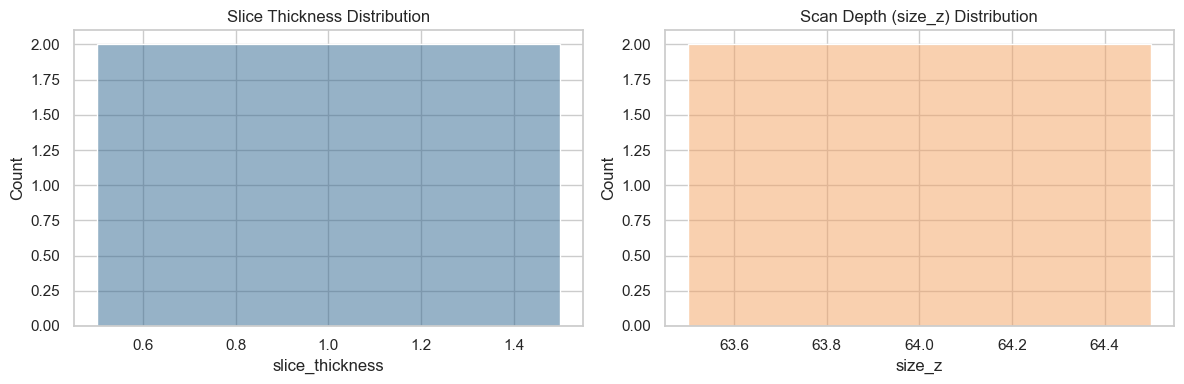

In [4]:
plot_cols = ['slice_thickness', 'size_z']
available_plot_cols = [c for c in plot_cols if c in df.columns]

if df.empty:
    print('No metadata rows available to plot.')
elif len(available_plot_cols) < 2:
    print(f'Missing plot columns. Available: {available_plot_cols}')
else:
    plot_df = df[plot_cols].dropna().copy()
    if plot_df.empty:
        print('Plot columns are present, but all values are missing.')
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(data=plot_df, x='slice_thickness', kde=True, ax=axes[0], color='#2f6690')
        axes[0].set_title('Slice Thickness Distribution')
        sns.histplot(data=plot_df, x='size_z', kde=True, ax=axes[1], color='#f4a261')
        axes[1].set_title('Scan Depth (size_z) Distribution')
        plt.tight_layout()
        plt.show()